## RQ2 - F4 Boxplots


Reading: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\1_Main_Spreadsheet\3.2_Total_Repo.csv


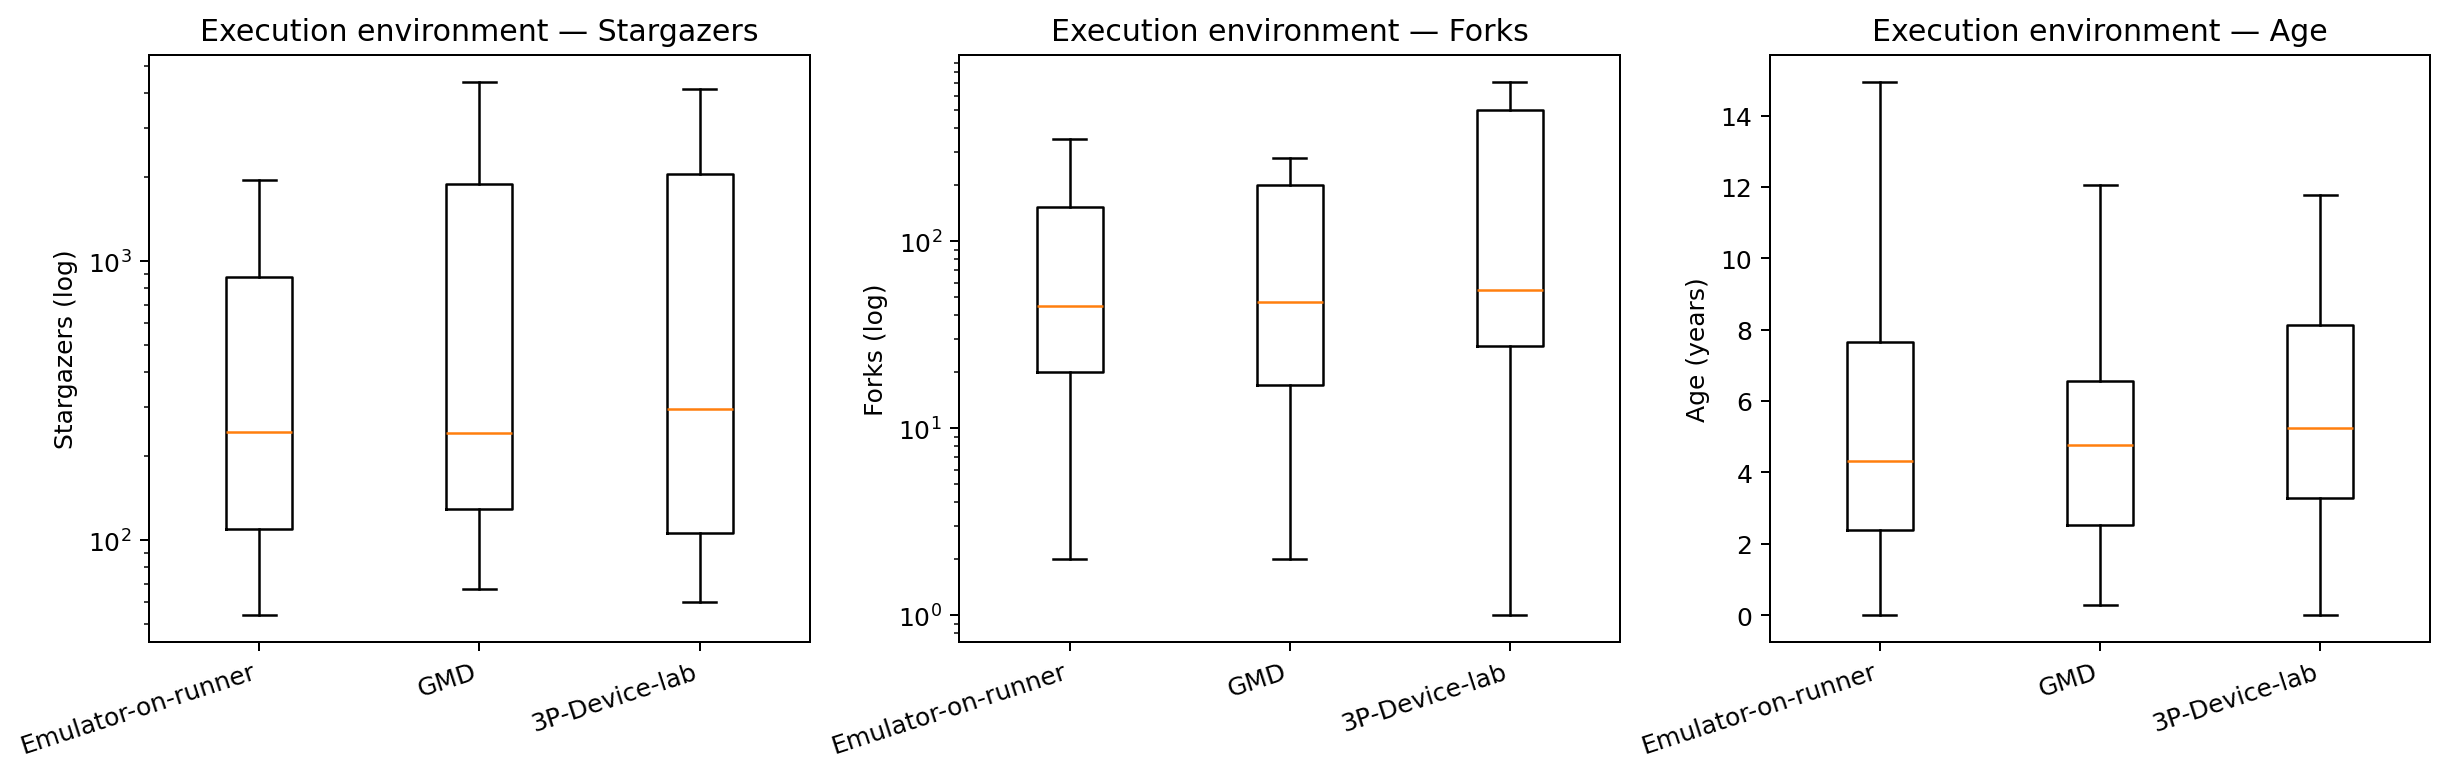

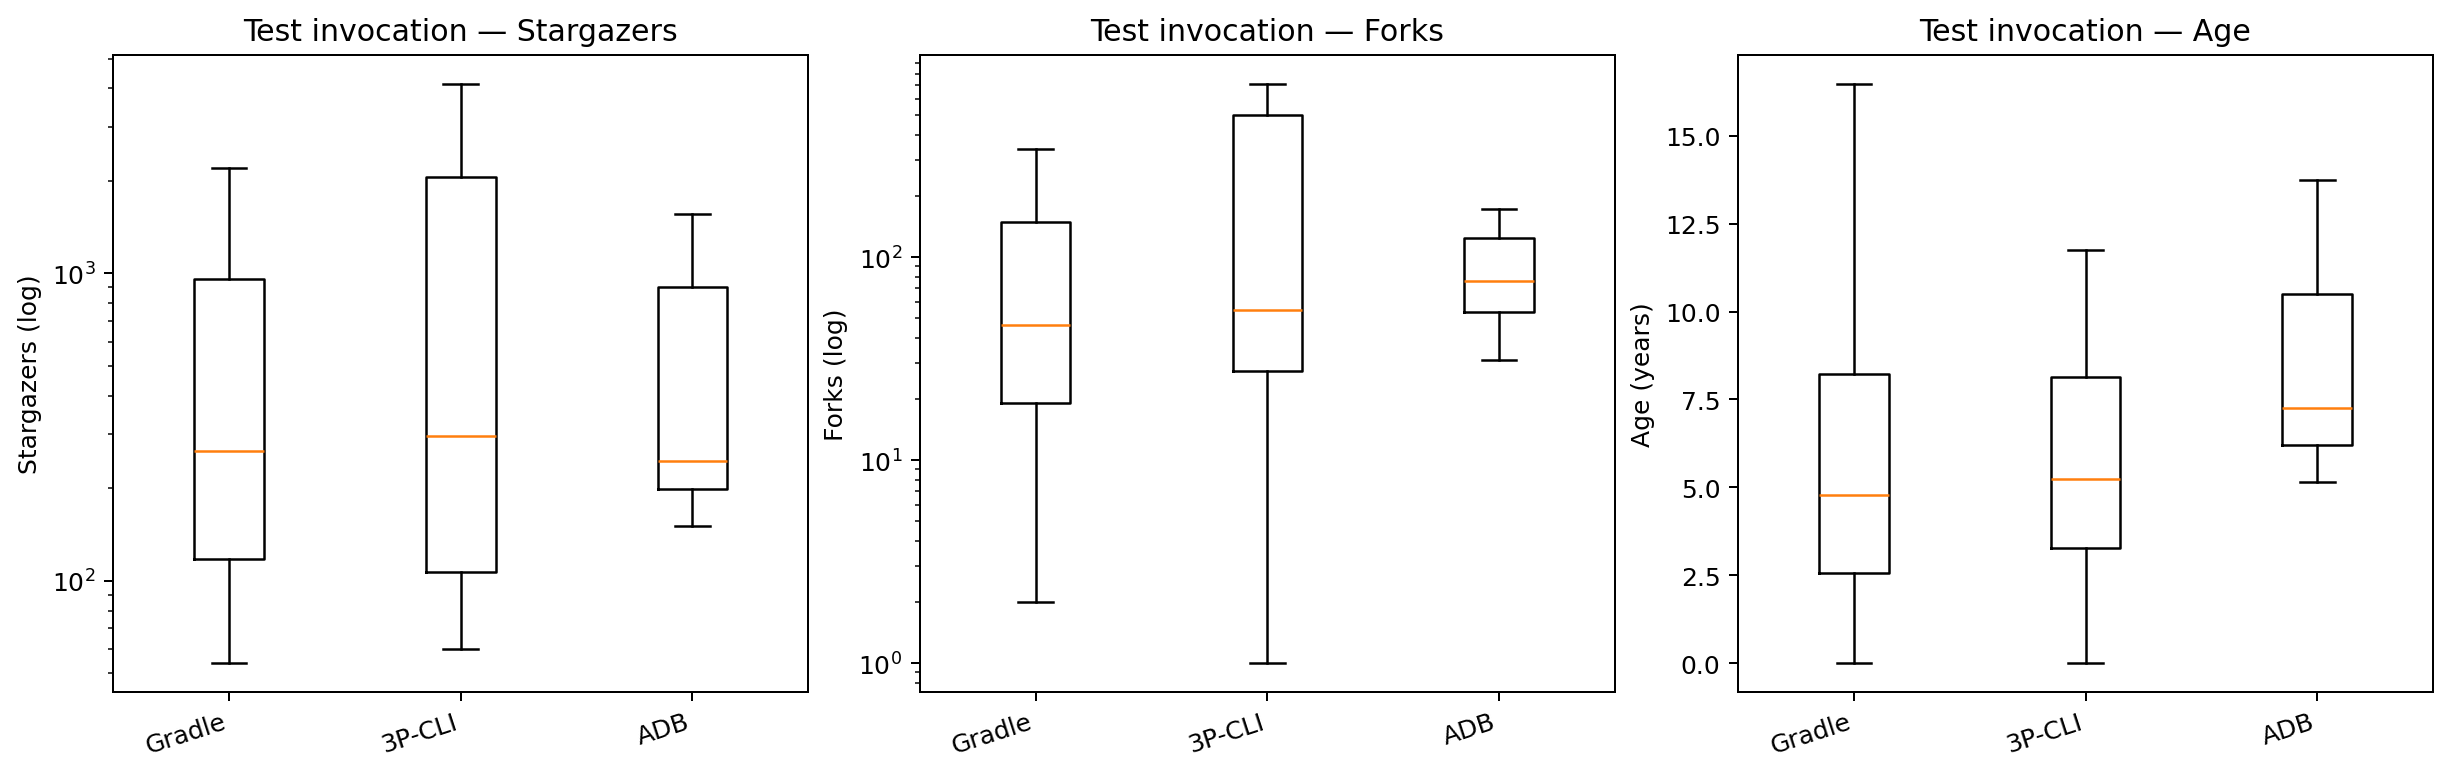

In [6]:
# -*- coding: utf-8 -*-
"""
Box plots for RQ2.4 — execution environments and test invocations (Adopters subset)
- Short labels
- Excludes "Physical device" from execution-environment plots
- Shows figures (does not save)
- NO cohort sizes in x-axis labels
"""

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# CONFIG — update if needed
# -----------------------------
DATA_DIR = r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\1_Main_Spreadsheet"
FILE_NAME = None  # e.g., "5.0_Total_Repo.csv"; keep None to auto-pick the first CSV in the folder
USE_ADOPTERS_ONLY = True
USE_INSTRUMENTATION_ONLY = True
LOG_METRICS_ADD_ONE = True  # add +1 before log scale so zeros are allowed

# Canonical long labels -> short labels
ENV_SHORT = {
    "Emulator on the CI runner": "Emulator-on-runner",
    "Gradle Managed Devices (GMD)": "GMD",
    "Third-party device lab": "3P-Device-lab",
    "Physical device": "Real-device",  # will be excluded from plots
}
INV_SHORT = {
    "Gradle-based": "Gradle",
    "Third-party CLI": "3P-CLI",
    "ADB": "ADB",
}

# Order of styles to display (short labels)
ENV_ORDER_SHORT = ["Emulator-on-runner", "GMD", "3P-Device-lab"]  # excludes "Real-device"
INV_ORDER_SHORT = ["Gradle", "3P-CLI", "ADB"]

# -----------------------------
# Helpers
# -----------------------------
def find_csv(path_dir: str, file_name: str | None) -> Path:
    p = Path(path_dir)
    if file_name:
        fp = p / file_name
        if not fp.exists():
            raise FileNotFoundError(f"CSV not found: {fp}")
        return fp
    candidates = sorted(p.glob("*Total*Repo*.csv")) or sorted(p.glob("*.csv"))
    if not candidates:
        raise FileNotFoundError(f"No CSV found under: {p}")
    return candidates[0]

def parse_dates_and_age(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    for col in ["created_at", "updated_at", "pushed_at"]:
        df[col + "_dt"] = pd.to_datetime(df.get(col), utc=True, errors="coerce")
    ref_dt = df["pushed_at_dt"].fillna(df["updated_at_dt"]).fillna(df["created_at_dt"])
    age_days = (ref_dt - df["created_at_dt"]).dt.total_seconds() / (60 * 60 * 24)
    df["age_years"] = age_days / 365.25
    return df

def split_labels(s):
    if pd.isna(s):
        return []
    return [x.strip() for x in str(s).split(",") if x and str(x).strip().lower() != "nan"]

def map_env_labels_raw_to_long(labels):
    """
    Raw examples: Emulator_Generic, Emulator_ReactiveCircus, Emulator_Malinskiy, Emulator_GMD,
                  Third Party, Real Device, Emulator_DIY, Emulator_Other
    """
    mapped = set()
    for lab in labels:
        low = lab.strip().lower()
        if low == "emulator_gmd":
            mapped.add("Gradle Managed Devices (GMD)")
        elif low.startswith("emulator_"):
            mapped.add("Emulator on the CI runner")
        elif low == "third party":
            mapped.add("Third-party device lab")
        elif low == "real device":
            mapped.add("Physical device")
    return mapped

def map_inv_labels_raw_to_long(labels):
    """
    Raw examples: Gradle, Gradle_Connected, Gradle_GMD, 3P CLIs, ADB
    """
    mapped = set()
    for lab in labels:
        low = lab.strip().lower()
        if low.startswith("gradle"):
            mapped.add("Gradle-based")
        elif low == "3p clis":
            mapped.add("Third-party CLI")
        elif low == "adb":
            mapped.add("ADB")
    return mapped

def explode_multi_short(df_base: pd.DataFrame, label_col: str, raw_mapper, short_map: dict, exclude_shorts: set[str] = None) -> pd.DataFrame:
    """
    Returns long-form rows with short labels:
    - raw labels -> canonical long labels -> short labels
    - optionally excludes styles with short labels in exclude_shorts
    """
    exclude_shorts = exclude_shorts or set()
    rows = []
    for _, row in df_base.iterrows():
        long_labels = raw_mapper(split_labels(row.get(label_col)))
        if not long_labels:
            continue
        base = {
            "stargazers_count": row.get("stargazers_count"),
            "forks_count": row.get("forks_count"),
            "age_years": row.get("age_years"),
        }
        for long_lab in long_labels:
            short_lab = short_map.get(long_lab)
            if short_lab is None or short_lab in exclude_shorts:
                continue
            r = dict(base)
            r["style"] = short_lab
            rows.append(r)
    return pd.DataFrame(rows)

def make_group_boxplots(df_long: pd.DataFrame, style_order_short: list[str], title_prefix: str):
    """Show one figure with three subplots (stars, forks, age) for the provided cohort. No cohort sizes in labels."""
    metrics = [
        ("stargazers_count", "Stargazers (log)"),
        ("forks_count", "Forks (log)"),
        ("age_years", "Age (years)"),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2), dpi=180, constrained_layout=True)

    for ax, (metric, ylabel) in zip(axes, metrics):
        data = []
        labels = []
        for style in style_order_short:
            vals = pd.to_numeric(df_long.loc[df_long["style"] == style, metric], errors="coerce").dropna().astype(float)
            if metric != "age_years" and LOG_METRICS_ADD_ONE:
                vals = vals + 1.0  # allow zeros on log scale
            data.append(vals.values)
            labels.append(style)  # NO cohort sizes in labels

        # Skip entirely empty cohorts (just in case)
        nonempty = [(d, l) for d, l in zip(data, labels) if len(d) > 0]
        if not nonempty:
            ax.set_visible(False)
            continue
        data, labels = zip(*nonempty)

        ax.boxplot(data, showfliers=False)
        ax.set_xticklabels(labels, rotation=18, ha="right")
        ax.set_ylabel(ylabel)
        if metric != "age_years":
            ax.set_yscale("log")
        ax.set_title(f"{title_prefix} — {ylabel.split('(')[0].strip()}")

    return fig, axes

# -----------------------------
# Main
# -----------------------------
def main():
    csv_path = find_csv(DATA_DIR, FILE_NAME)
    print(f"Reading: {csv_path}")
    df = pd.read_csv(csv_path)

    if USE_ADOPTERS_ONLY and "Adopters" in df.columns:
        df = df[df["Adopters"] == True].copy()
    if USE_INSTRUMENTATION_ONLY and "Instru_test" in df.columns:
        df = df[df["Instru_test"] == True].copy()

    df = parse_dates_and_age(df)

    # Sanity check
    for required in ["execution_environment", "test_invocation", "stargazers_count", "forks_count"]:
        if required not in df.columns:
            raise KeyError(f"Missing column: {required}")

    # Build long-form data with short labels
    env_long_short = explode_multi_short(
        df, "execution_environment", map_env_labels_raw_to_long, ENV_SHORT,
        exclude_shorts={"Real device"}  # exclude physical/real device from plotting
    )
    inv_long_short = explode_multi_short(
        df, "test_invocation", map_inv_labels_raw_to_long, INV_SHORT
    )

    # Show grouped box plots (no saving)
    make_group_boxplots(env_long_short, ENV_ORDER_SHORT, "Execution environment")
    make_group_boxplots(inv_long_short, INV_ORDER_SHORT, "Test invocation")

    plt.show()

if __name__ == "__main__":
    main()
